# CarDD — Model Comparison: YOLO11l vs YOLOv8l-P2




## 0 · Imports  

In [1]:
%matplotlib inline
import os, glob, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Image as IPyImage
import cv2, torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)
pd.set_option("display.width", 160)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CLASS_COLORS = ['#F97066', '#5B9CF6', '#63D0A8', '#FBBF24', '#C084FC', '#FB923C']
IMGSZ = 1024
CONF_VIS = 0.25


Device: 0 | NVIDIA GeForce RTX 4080 SUPER


## 1 · Locate the two training runs (auto)

In [2]:
HERE = Path.cwd()
RUNS_DIR = HERE / "runs"
assert RUNS_DIR.exists(), f"runs/ not found at {RUNS_DIR}. Keep this notebook in CarDD/model/."

# friendly name -> substring; excludes polish folders unless you change this
MODEL_PATTERNS = {
    "YOLO11l":    "01_yolo11l",
    "YOLOv8l-P2": "02_yolov8l_p2",
}
EXCLUDE = ("polish",)   # set to () if you want polish runs eligible

def _epochs_in(d):
    csv = d / "results.csv"
    return (sum(1 for _ in open(csv)) - 1) if csv.exists() else 0

def find_run(pattern):
    cands = [d for d in sorted(RUNS_DIR.glob("*"))
             if d.is_dir() and (d / "weights" / "best.pt").exists()
             and pattern in d.name and not any(e in d.name for e in EXCLUDE)]
    return max(cands, key=_epochs_in) if cands else None

MODELS = {}
for name, pat in MODEL_PATTERNS.items():
    rd = find_run(pat)
    if rd is None:
        print(f"  [MISSING] no run matching '{pat}'")
    else:
        MODELS[name] = rd
        print(f"  {name:12s} -> {rd.name}  ({_epochs_in(rd)} epochs)")
assert len(MODELS) == 2, "Need both runs. Adjust MODEL_PATTERNS / EXCLUDE above."

OUTDIR = HERE / "comparison_output"; OUTDIR.mkdir(exist_ok=True)
print("\nSaving artifacts to:", OUTDIR)


  YOLO11l      -> 01_yolo11l  (106 epochs)
  YOLOv8l-P2   -> 02_yolov8l_p2-2  (46 epochs)

Saving artifacts to: c:\Users\AFA001\Downloads\CarDD_transfer\model\comparison_output


## 2 · Resolve dataset paths (portable)

In [3]:
import yaml
ROOT = next((c for c in [HERE, *HERE.parents] if (c / "data_balanced.yaml").exists()), None)
assert ROOT is not None, "data_balanced.yaml not found above this notebook."
with open(ROOT / "data_balanced.yaml") as f:
    dcfg = yaml.safe_load(f)
dcfg["path"] = str(ROOT).replace("\\", "/")
DATA_YAML = HERE / "data_local.yaml"
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(dcfg, f, sort_keys=False, allow_unicode=True)
TEST_IMAGES = ROOT / dcfg["test"]
print("Test images:", TEST_IMAGES, "| exists:", TEST_IMAGES.exists())


Test images: c:\Users\AFA001\Downloads\CarDD_transfer\enhanced\test\images | exists: True


## 3 · Evaluate both models on the **test** split

In [4]:
per_class_rows, overall_rows, test_plot_dirs = [], [], {}
for name, run_dir in MODELS.items():
    print(f"\n=== {name} ({run_dir.name}) on test ===")
    m = YOLO(str(run_dir / "weights" / "best.pt")).val(
        data=str(DATA_YAML), split="test", imgsz=IMGSZ, conf=0.001, device=DEVICE,
        plots=True, project=str(OUTDIR), name=f"test_{name}", exist_ok=True, verbose=False)
    test_plot_dirs[name] = Path(m.save_dir)
    overall_rows.append({"model": name, "mAP50": round(float(m.box.map50), 4),
                         "mAP50-95": round(float(m.box.map), 4), "mAP75": round(float(m.box.map75), 4),
                         "precision": round(float(m.box.mp), 4), "recall": round(float(m.box.mr), 4)})
    for i, c in enumerate(m.box.ap_class_index):
        per_class_rows.append({"model": name, "class": m.names[c],
                               "AP50": round(float(m.box.ap50[i]), 4),
                               "AP50-95": round(float(m.box.ap[i]), 4),
                               "precision": round(float(m.box.p[i]), 4),
                               "recall": round(float(m.box.r[i]), 4)})
overall = pd.DataFrame(overall_rows).set_index("model")
per_class = pd.DataFrame(per_class_rows)
print("\nEvaluation complete.")



=== YOLO11l (01_yolo11l) on test ===
Ultralytics 8.4.66  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11l summary (fused): 191 layers, 25,283,938 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3447.21248.0 MB/s, size: 282.1 KB)
val: Scanning C:\Users\AFA001\Downloads\CarDD_transfer\enhanced\test\labels.cache... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.5it/s 5.3s0.2s
                   all        374        785      0.795      0.668      0.725      0.557
Speed: 1.2ms preprocess, 10.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\AFA001\Downloads\CarDD_transfer\model\comparison_output\test_YOLO11l

=== YOLOv8l-P2 (02_yolov8l_p2-2) on test ===
Ultralytics 8.4.66  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 1

## 4 · Overall comparison

>>> Overall test metrics:


,mAP50,mAP50-95,mAP75,precision,recall
model,,,,,
YOLO11l,0.7247,0.5569,0.5887,0.7949,0.6682
YOLOv8l-P2,0.7214,0.5410,0.5708,0.7480,0.7013


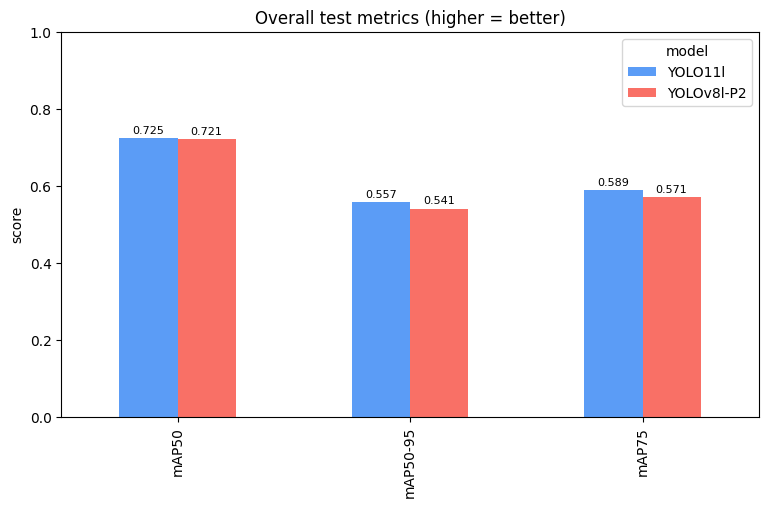

Overall mAP50-95 winner: YOLO11l


In [5]:
overall.to_csv(OUTDIR / "overall_comparison.csv")
print(">>> Overall test metrics:")
display(overall)

fig, ax = plt.subplots(figsize=(9, 5))
overall[["mAP50", "mAP50-95", "mAP75"]].T.plot(kind="bar", ax=ax, color=["#5B9CF6", "#F97066"])
ax.set_title("Overall test metrics (higher = better)"); ax.set_ylabel("score"); ax.set_ylim(0, 1)
ax.legend(title="model")
for cont in ax.containers: ax.bar_label(cont, fmt="%.3f", fontsize=8, padding=2)
fig.savefig(OUTDIR / "fig_overall.png", dpi=120, bbox_inches="tight")
plt.show()
print("Overall mAP50-95 winner:", overall["mAP50-95"].idxmax())


## 5 · Per-class comparison (key view)

>>> Per-class AP50-95:


model,YOLO11l,YOLOv8l-P2,delta (B-A),winner
class,,,,
crack,0.2530,0.2555,0.0025,YOLOv8l-P2
scratch,0.3087,0.2809,-0.0278,YOLO11l
dent,0.3439,0.3226,-0.0213,YOLO11l
lamp_broken,0.7163,0.6887,-0.0276,YOLO11l
tire_flat,0.8593,0.8385,-0.0208,YOLO11l
glass_shatter,0.8600,0.8596,-0.0004,YOLO11l


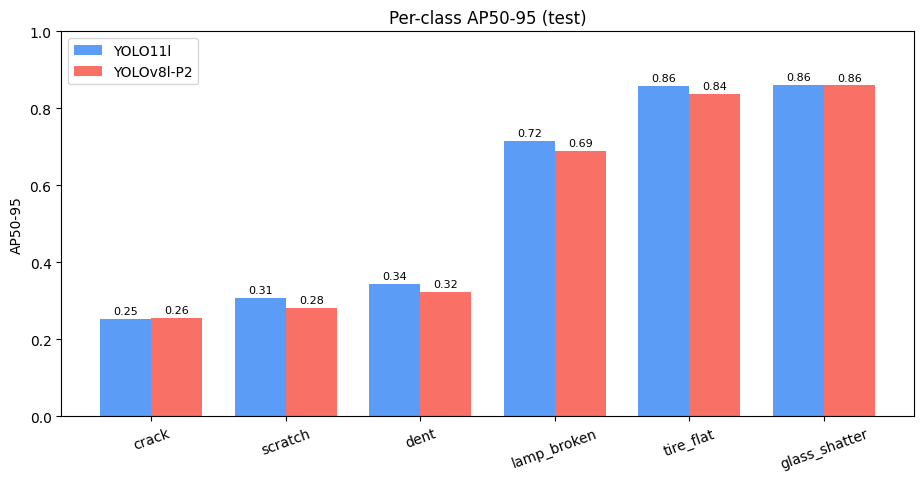

YOLOv8l-P2 beats YOLO11l on 1/6 classes.


In [6]:
names = list(MODELS.keys()); a, b = names[0], names[1]
piv = per_class.pivot(index="class", columns="model", values="AP50-95")[[a, b]]
piv["delta (B-A)"] = (piv[b] - piv[a]).round(4)
piv["winner"] = np.where(piv[b] > piv[a], b, a)
piv = piv.sort_values(a)

per_class.pivot(index="class", columns="model",
                values=["AP50", "AP50-95", "precision", "recall"]).to_csv(OUTDIR / "per_class_comparison.csv")
print(">>> Per-class AP50-95:")
display(piv)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(piv)); w = 0.38
ax.bar(x - w/2, piv[a], w, label=a, color="#5B9CF6")
ax.bar(x + w/2, piv[b], w, label=b, color="#F97066")
ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=20)
ax.set_ylabel("AP50-95"); ax.set_ylim(0, 1); ax.set_title("Per-class AP50-95 (test)"); ax.legend()
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
fig.savefig(OUTDIR / "fig_perclass.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"{b} beats {a} on {(piv[b] > piv[a]).sum()}/{len(piv)} classes.")


## 6 · Training curves

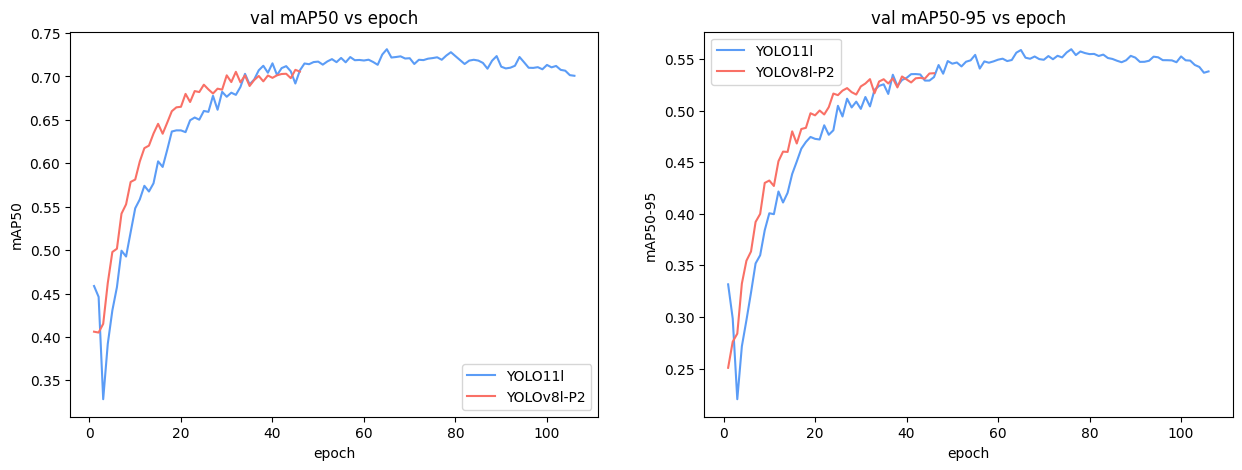

In [7]:
def load_results(run_dir):
    df = pd.read_csv(run_dir / "results.csv"); df.columns = df.columns.str.strip(); return df
def find_col(df, key):
    return next((c for c in df.columns if key in c), None)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
colors = {names[0]: "#5B9CF6", names[1]: "#F97066"}
for name, run_dir in MODELS.items():
    df = load_results(run_dir)
    ep_col = find_col(df, "epoch"); ep = df[ep_col] if ep_col else range(len(df))
    c50, c95 = find_col(df, "mAP50("), find_col(df, "mAP50-95")
    if c50: ax[0].plot(ep, df[c50], label=name, color=colors[name])
    if c95: ax[1].plot(ep, df[c95], label=name, color=colors[name])
ax[0].set(title="val mAP50 vs epoch", xlabel="epoch", ylabel="mAP50"); ax[0].legend()
ax[1].set(title="val mAP50-95 vs epoch", xlabel="epoch", ylabel="mAP50-95"); ax[1].legend()
fig.savefig(OUTDIR / "fig_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 7 · Result plots side-by-side

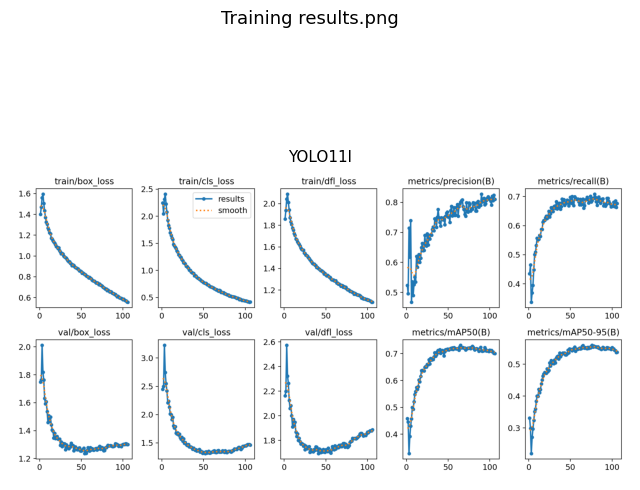

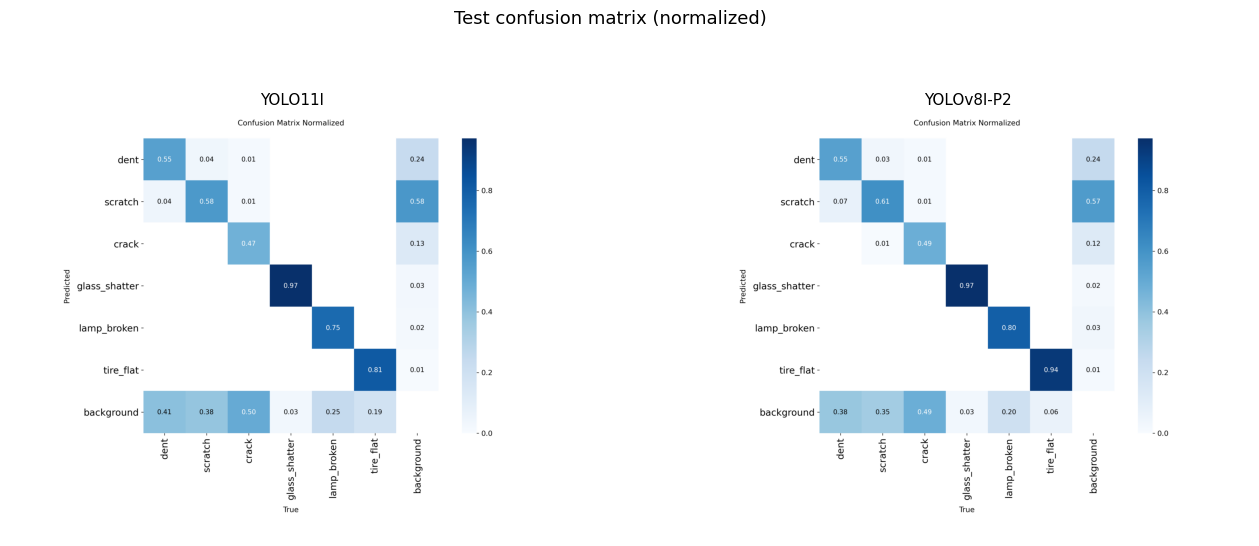

(missing images for: Test Precision-Recall curve )


In [8]:
def show_side_by_side(items, suptitle, save_as, fes=(8, 6)):
    valid = [(t, p) for t, p in items if p and Path(p).exists()]
    if not valid:
        print("(missing images for:", suptitle, ")"); return
    n = len(valid)
    fig, axes = plt.subplots(1, n, figsize=(fes[0]*n, fes[1]))
    if n == 1: axes = [axes]
    for ax, (t, p) in zip(axes, valid):
        ax.imshow(plt.imread(str(p))); ax.set_title(t, fontsize=11); ax.axis("off")
    fig.suptitle(suptitle, fontsize=13, y=1.02)
    fig.savefig(OUTDIR / save_as, dpi=120, bbox_inches="tight")
    plt.show()

show_side_by_side([(n, MODELS[n] / "results.png") for n in names],
                  "Training results.png", "fig_results_png.png")
show_side_by_side([(n, test_plot_dirs[n] / "confusion_matrix_normalized.png") for n in names],
                  "Test confusion matrix (normalized)", "fig_confusion.png")
show_side_by_side([(n, test_plot_dirs[n] / "PR_curve.png") for n in names],
                  "Test Precision-Recall curve", "fig_pr_curve.png")


## 8 · Prediction comparison on the same test images

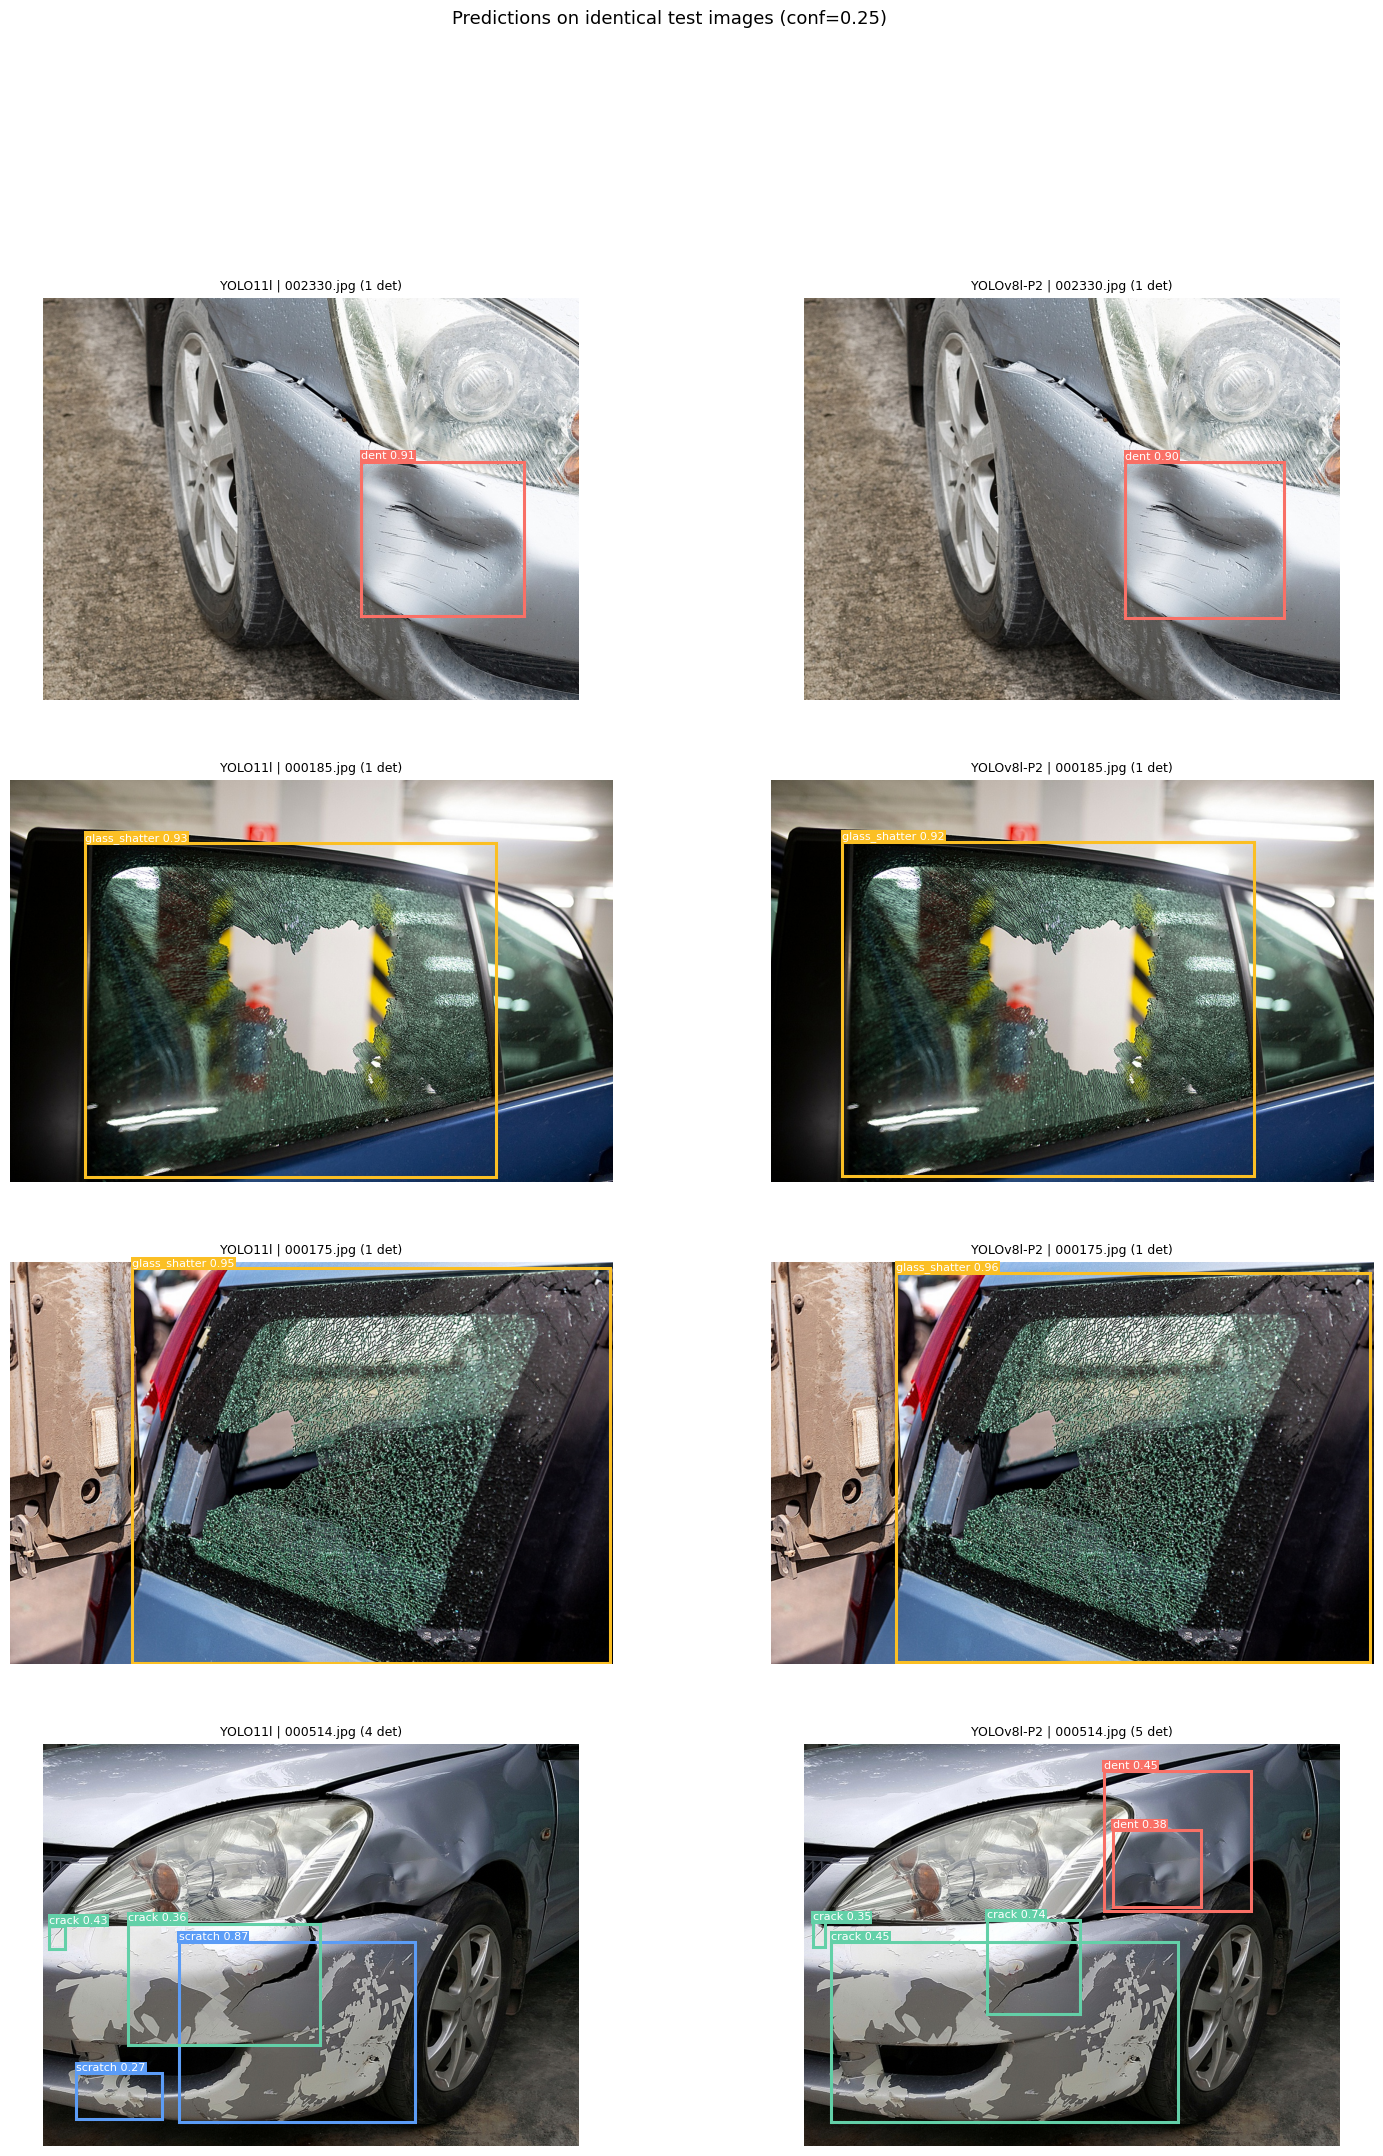

In [9]:
all_imgs = sorted(str(p) for p in TEST_IMAGES.glob("*.jpg"))
sample = random.sample(all_imgs, min(4, len(all_imgs)))
loaded = {n: YOLO(str(MODELS[n] / "weights" / "best.pt")) for n in names}

def draw(ax, img_path, model, title):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    res = model(img_path, conf=CONF_VIS, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    ax.imshow(img)
    for bx in res.boxes:
        x1, y1, x2, y2 = bx.xyxy[0].cpu().numpy()
        cid = int(bx.cls[0]); cf = float(bx.conf[0]); col = CLASS_COLORS[cid % len(CLASS_COLORS)]
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=col, lw=2.2))
        ax.text(x1, max(y1-4, 0), f"{res.names[cid]} {cf:.2f}", color="white", fontsize=8,
                bbox=dict(facecolor=col, edgecolor="none", pad=1))
    ax.set_title(f"{title} ({len(res.boxes)} det)", fontsize=9); ax.axis("off")

fig, axes = plt.subplots(len(sample), len(names), figsize=(9*len(names), 6*len(sample)))
if len(sample) == 1: axes = axes[None, :]
for r, img_path in enumerate(sample):
    for cidx, n in enumerate(names):
        draw(axes[r, cidx], img_path, loaded[n], f"{n} | {Path(img_path).name}")
fig.suptitle(f"Predictions on identical test images (conf={CONF_VIS})", fontsize=13, y=1.0)
fig.savefig(OUTDIR / "fig_predictions.png", dpi=120, bbox_inches="tight")
plt.show()


## 9 · Winner summary

In [10]:
lines = ["CarDD model comparison — TEST split", "=" * 50]
for n in names:
    lines.append(f"{n:12s}  mAP50={overall.loc[n,'mAP50']:.4f}  "
                 f"mAP50-95={overall.loc[n,'mAP50-95']:.4f}  (run: {MODELS[n].name})")
lines += ["-" * 50,
          f"Overall mAP50-95 winner : {overall['mAP50-95'].idxmax()}",
          f"Overall mAP50 winner    : {overall['mAP50'].idxmax()}",
          f"{b} wins per-class (AP50-95): {(piv[b] > piv[a]).sum()}/{len(piv)}",
          "", "Per-class AP50-95:", piv.to_string()]
summary = "\n".join(lines)
print(summary)
with open(OUTDIR / "summary.txt", "w") as f: f.write(summary)
print("\nSaved files in", OUTDIR, ":")
for p in sorted(OUTDIR.glob("*")):
    print("  -", p.name)


CarDD model comparison — TEST split
YOLO11l       mAP50=0.7247  mAP50-95=0.5569  (run: 01_yolo11l)
YOLOv8l-P2    mAP50=0.7214  mAP50-95=0.5410  (run: 02_yolov8l_p2-2)
--------------------------------------------------
Overall mAP50-95 winner : YOLO11l
Overall mAP50 winner    : YOLO11l
YOLOv8l-P2 wins per-class (AP50-95): 1/6

Per-class AP50-95:
model          YOLO11l  YOLOv8l-P2  delta (B-A)      winner
class                                                      
crack           0.2530      0.2555       0.0025  YOLOv8l-P2
scratch         0.3087      0.2809      -0.0278     YOLO11l
dent            0.3439      0.3226      -0.0213     YOLO11l
lamp_broken     0.7163      0.6887      -0.0276     YOLO11l
tire_flat       0.8593      0.8385      -0.0208     YOLO11l
glass_shatter   0.8600      0.8596      -0.0004     YOLO11l

Saved files in c:\Users\AFA001\Downloads\CarDD_transfer\model\comparison_output :
  - fig_confusion.png
  - fig_curves.png
  - fig_overall.png
  - fig_perclass.png
  - fig_